In [4]:
import matplotlib.pyplot as plt
import numpy as np


VOXEL_SIZE = {"z": 1.0, "y": 0.24, "x": 0.24}  # µm/px

In [2]:
def plot_nn_threshold_comparison(
    voxel_size,
    r_iso_um,
    r_xy_um,
    r_z_um,
):
    """
    Compare an isotropic sphere threshold vs a PSF-matched ellipsoid threshold,
    showing the pixel inclusion footprint in XY and XZ cross-sections.

    Parameters
    ----------
    voxel_size : dict  {"z": µm/px, "y": µm/px, "x": µm/px}
    r_iso_um   : float  radius of the current isotropic sphere (µm)
    r_xy_um    : float  lateral semi-axis of the PSF ellipsoid (µm)
    r_z_um     : float  axial semi-axis of the PSF ellipsoid (µm)
    """
    vz, vy, vx = voxel_size["z"], voxel_size["y"], voxel_size["x"]

    r_iso_px_xy = r_iso_um / vx
    r_iso_px_z  = r_iso_um / vz
    r_xy_px     = r_xy_um  / vx
    r_z_px      = r_z_um   / vz

    def _in_sphere(xi, yi, zi):
        return (xi*vx)**2 + (yi*vy)**2 + (zi*vz)**2 <= r_iso_um**2

    def _in_ellipsoid(xi, yi, zi):
        return (xi*vx/r_xy_um)**2 + (yi*vy/r_xy_um)**2 + (zi*vz/r_z_um)**2 <= 1.0

    theta    = np.linspace(0, 2*np.pi, 300)
    grid_max = int(np.ceil(max(r_iso_px_xy, r_z_px))) + 2

    configs = [
        ("Isotropic sphere",   _in_sphere,    (r_iso_px_xy, r_iso_px_xy), (r_iso_px_xy, r_iso_px_z),  "steelblue"),
        ("PSF ellipsoid",      _in_ellipsoid, (r_xy_px,     r_xy_px),     (r_xy_px,     r_z_px),       "mediumseagreen"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    fig.suptitle(
        f"Isotropic sphere (r={r_iso_um} µm)  vs  PSF ellipsoid "
        f"(r_xy={r_xy_um} µm, r_z={r_z_um} µm)\n"
        f"voxel: z={vz}, y={vy}, x={vx} µm/px",
        fontsize=11,
    )

    print(f"{'':30s}  {'XY px':>6}  {'XZ px':>6}")
    for row_i, (label, in_fn, (ex_xy, ey_xy), (ex_xz, ez_xz), color) in enumerate(configs):
        ax_xy = axes[row_i, 0]
        ax_xz = axes[row_i, 1]

        for ax in (ax_xy, ax_xz):
            for i in range(-grid_max, grid_max + 1):
                ax.axhline(i - 0.5, color="lightgrey", lw=0.4)
                ax.axvline(i - 0.5, color="lightgrey", lw=0.4)

        n_xy = n_xz = 0
        for xi in range(-grid_max, grid_max + 1):
            for yi in range(-grid_max, grid_max + 1):
                if in_fn(xi, yi, 0):
                    ax_xy.add_patch(plt.Rectangle((xi-.5, yi-.5), 1, 1, color=color, alpha=0.4, zorder=1))
                    n_xy += 1
            for zi in range(-grid_max, grid_max + 1):
                if in_fn(xi, 0, zi):
                    ax_xz.add_patch(plt.Rectangle((xi-.5, zi-.5), 1, 1, color=color, alpha=0.4, zorder=1))
                    n_xz += 1

        ax_xy.plot(np.cos(theta)*ex_xy, np.sin(theta)*ey_xy, "r-", lw=2, zorder=3)
        ax_xz.plot(np.cos(theta)*ex_xz, np.sin(theta)*ez_xz, "r-", lw=2, zorder=3)

        for ax in (ax_xy, ax_xz):
            ax.plot(0, 0, "k+", ms=10, mew=2, zorder=4)
            ax.set_xlim(-grid_max, grid_max)
            ax.set_ylim(-grid_max, grid_max)
            ax.set_aspect("equal")

        ax_xy.set_xlabel("X (px)"); ax_xy.set_ylabel("Y (px)")
        ax_xz.set_xlabel("X (px)"); ax_xz.set_ylabel("Z (px)")
        ax_xy.set_title(f"{label} — XY  ({n_xy} px included)")
        ax_xz.set_title(f"{label} — XZ  ({n_xz} px included)")
        print(f"  {label:28s}  {n_xy:>6}  {n_xz:>6}")

    print(f"\nKDTree ellipsoid trick: scale coords by (1/r_xy, 1/r_xy, 1/r_z) µm⁻¹, query threshold=1.0")
    print(f"  scale_xy = 1/{r_xy_um} = {1/r_xy_um:.3f}  |  scale_z = 1/{r_z_um} = {1/r_z_um:.3f}")

    fig.tight_layout()
    plt.show()




                                 XY px   XZ px
  Isotropic sphere                  13       5
  PSF ellipsoid                     13      11

KDTree ellipsoid trick: scale coords by (1/r_xy, 1/r_xy, 1/r_z) µm⁻¹, query threshold=1.0
  scale_xy = 1/0.5 = 2.000  |  scale_z = 1/1.25 = 0.800


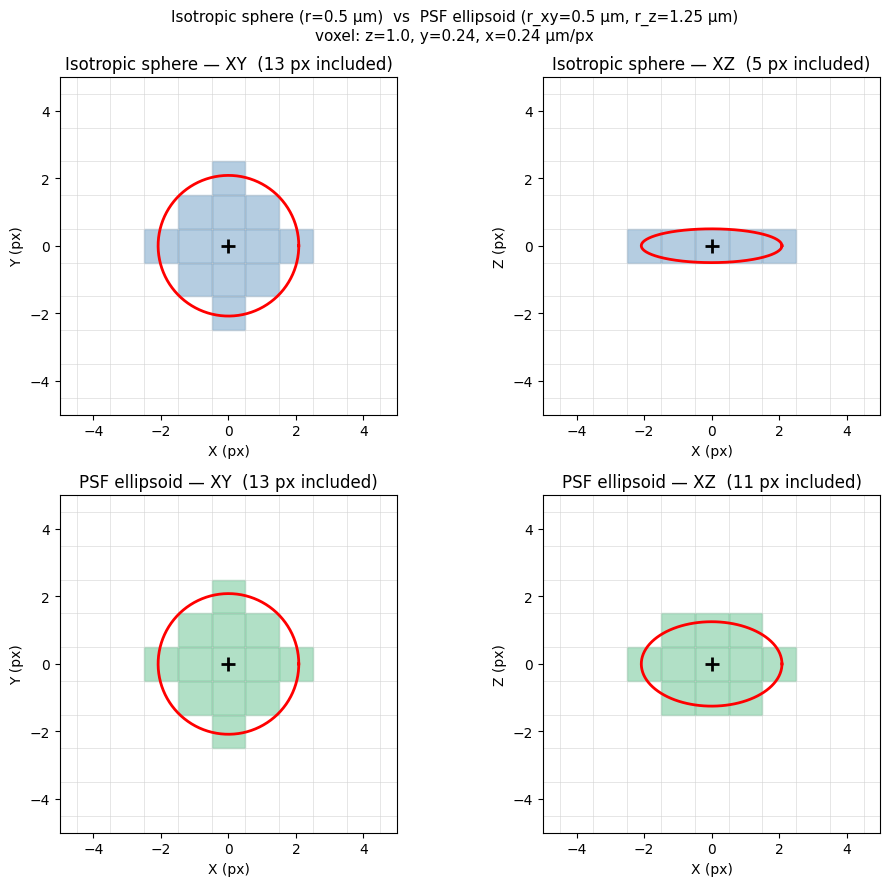

In [7]:
DIST_THRESHOLD_UM = .5   # µm — the unmixing distance_threshold
plot_nn_threshold_comparison(
    voxel_size=VOXEL_SIZE,
    r_iso_um=DIST_THRESHOLD_UM,
    r_xy_um=.5,
    r_z_um=1.25,
)

## Legacy unmixing, min_dist = 3

                                 XY px   XZ px
  Isotropic sphere                  13       5
  PSF ellipsoid                     29      29

KDTree ellipsoid trick: scale coords by (1/r_xy, 1/r_xy, 1/r_z) µm⁻¹, query threshold=1.0
  scale_xy = 1/0.75 = 1.333  |  scale_z = 1/3.0 = 0.333


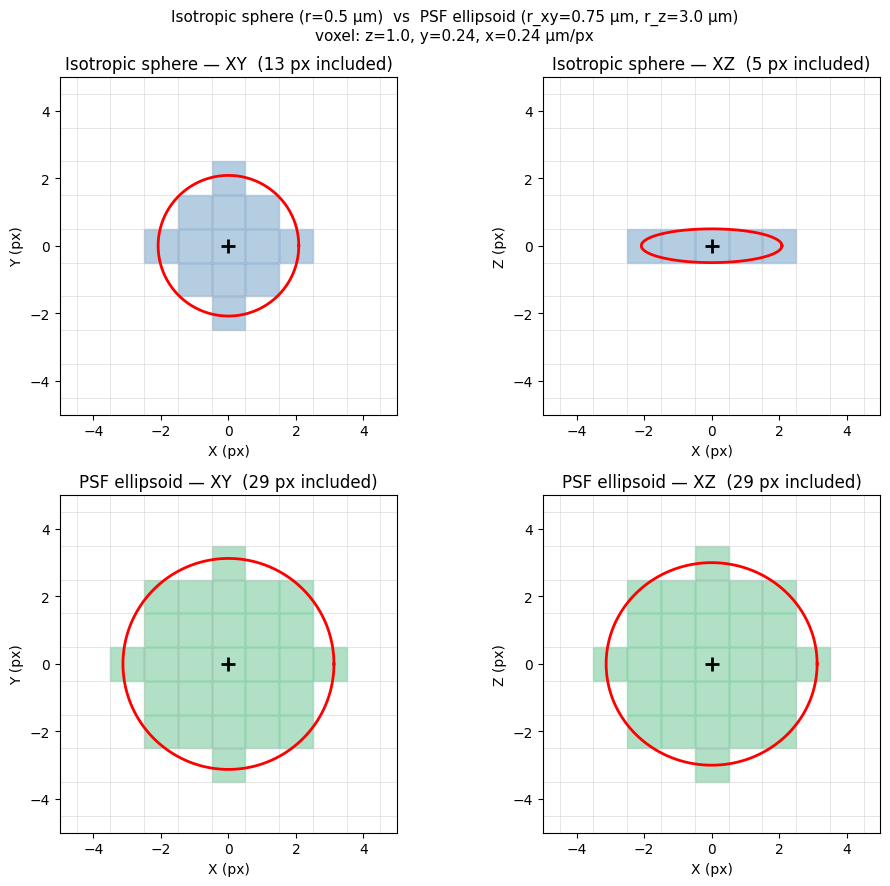

In [6]:
DIST_THRESHOLD_UM = .5   # µm — the unmixing distance_threshold
plot_nn_threshold_comparison(
    voxel_size=VOXEL_SIZE,
    r_iso_um=DIST_THRESHOLD_UM,
    r_xy_um=.75,
    r_z_um=3.0,
)